# **Does bid-ask spread explains the smile? On DVF and DML**

*Main Reference: [Li, Lin, Yu, Liu (2025)](https://www.sciencedirect.com/science/article/abs/pii/S0927538X24003974?utm_source=chatgpt.com)*

*Author: Francesco Mosti*\
*[Github Profile](https://github.com/FrancescoMosti)*

*Institute: University of Florence & IMT Lucca*\
*Course: Master in Data Science, Analytics in Economics and Business*\
*Supervisor: Prof. Massimo Riccaboni*

## Notebook Summary

This notebook replicates and extends the core findings of the paper ["Does bid-ask spread explain the smile?" by Li, Lin, Yu, Liu (2025)](https://www.sciencedirect.com/science/article/abs/pii/S0927538X24003974?utm_source=chatgpt.com), applying the Double Machine Learning (DML) framework by [Chernozhukov et al. (2018)]((https://academic.oup.com/ectj/article-abstract/21/1/C1/5056401?redirectedFrom=fulltext)) to estimate the causal effect of liquidity costs (bid-ask spread) on implied volatility.

## Theoretical introduction

Volatility is a statistical measure of dispersion of returns for a given security typically measured by the standard deviation of price movements over a specified period: a highly volatile stock is one that has large swings in price, whereas the opposite is defined when price variations are more stable.\
**Implied Volatility** (IV), often referred as projected volatility, is an estimation of future volatility of a stock (or index) inferred from current **option prices**. It can be considered as a metric that captures the market's view of the likelihood of changes in a given security's price.

> Implied Volatility is thus different from historical volatility, with the latter based on realized market changes.

IV is often used to price option contracts (high IV = options with higher premiums).\
IV is usually higher in bearish markets (period of prolonged price declines).

The critical point is that IV is not directly observable in the market but it has to be calculated using option pricing models, in particular it must be *inferred* from observed option prices.

### Black-Scholes model
The [**Black-Scholes**](https://en.wikipedia.org/wiki/Black–Scholes_model) model (starting point for every vanilla-pricing engine) as one of its main assumption considers the Implied Volatility to be constant for a options with the same strike prices and time-to-maturity.\
In reality, this is not true as IV is rarely (if never) stable. For this reason the Black-Scholes model is limited to European options which may only be exercised on the day of maturity, as opposed to American options exercisable at any time before expiration.\
This shortcoming have led some investors to place more importance on historical volatility rather than IV, resulting in not-so-accurate measures of future volatility during market regime shifts.

Changing **IV** also has its problems, as it can lead to extremely inaccurate estimates when options markets aren't sufficiently liquid. This situation leads to less stable market prices, influenced too much also by individual traders mistakes.

### Deterministic Volatility Function
To overcome the problem of constant Implied Volatility assumed in the BS-model, [**DVF**](https://www.cmat.edu.uy/~mordecki/hk/derman-kani.pdf) models were introduced (notably by Derman and Kani, 1994) to approximate implied volatility as a smooth deterministic function of underlying asset's strike price and time-to-maturity, thereby capturing more rigorously empirical patterns.

The variations in implied volatility are often referred as [Volatility Smile](https://corporatefinanceinstitute.com/resources/derivatives/volatility-smile/), where options with very extreme strike prices (very low or high: deep-in-the-money or deep-out-the-money options)  tend to have higher IV than at-the-money (ATM) options.\
These situations are particularly common in periods of high market distress, and thus should be considered when creating financial and pricing models.

![Volatility Smile](vsmile.PNG)

Several explanations for the volatility smile have been proposed. A leading hypothesis states that deep OTM and ITM options carry higher risk premiums, as they provide hedges against extreme market movements — especially in the presence of fat tails or jump risk. As a result, their prices (and implied volatilities) are systematically higher.\
Options models that go beyond the classic B-S have led to overpricing OTM options, in order to account for the excessive risk exposure associated with them (they have -currently- no intrinsic value, meaning that exercising them would result in losing money).

> It is worth noting that DVF models are still an approximation: the volatility smile is itself a *stylized representation* of how the market perceives risk, and may vary over time or across asset classes.

## Implementation and Objective of the analysis - Double Machine Learning

This notebook is implemented to try and replicate the work by [Li, Lin, Yu, Liu (2025)](https://www.sciencedirect.com/science/article/abs/pii/S0927538X24003974?utm_source=chatgpt.com).\
The authors worked on the `CSI 300` index that replicates the performance of the capitalization-weighted Chinese stock market.\
I will try to replicate the analysis on the `QQQ` index which tracks NASDAQ performance.
> Note that the work of the 4 authors is based on data collected between 23 December 2019 to 31 December 2023. In my case I will be forced to work on daily data from July 2025, since there is no free historical data on option fundamentals, that can be retrieved from `yfianance`.\
> However, it should be noticed that being the **QQQ** much more liquid (and not newly established as the **CSI 300**), the data at my disposal on a daily basis is much more larger than that of the original work: in particular the authors worked on 155'000 observations (calls and puts options) over 3 years, while I will work on nearly 5'000 daily observations, over a period of 2 days.

--------
#### Objective of the analysis
The main goal of the analysis is to employ the [Double Machine Learning (DML) - Chernouzhukov et. al. 2018](https://academic.oup.com/ectj/article-abstract/21/1/C1/5056401?redirectedFrom=fulltext) technique to evaluate the effect of liquidity cost (proxied by the bid-ask spread) on implied volatility, in the presence of economic confounders.\
In their research, the authors also showed that the Deterministic Volatility Function (DVF) modified to incorporate the bid-ask spread works better than the Black-Scholes model, and a sizeable liquidity costs effect on implied volatility is observed in the CSI 300 options market. This analysis will be implemented on a much higher-level, since the focus is on DML.

---

#### Double Machine Learning for causal inferene

This relatively recent technique for causal inference allows us to estimate the effect of a **treatment variable** (in our case, `liquidity`, proxied by the bid-ask spread) on an **outcome variable** (`implied volatility`), in the presence of **confounders**.

The framework can be expressed in the following form, in the partial linear model setting:

$$
Y = \theta_{0} D + g_0(X) + U \\
D = m_0(X) + V
$$

where:
- **Y** is the outcome (Implied Volatility)
- **D** is the treatment (Liquidity)
- **X** is a set of observed confounding variables (later presented)
- **$\theta_0$** is the parameter of interest
- **$g_0(X)$** = $\mathbb{E}[Y|X]$ and **$m_0(X)$** = $\mathbb{E}[D|X]$ are nuisance functions
- **U** and **V** are error terms with $\mathbb{E}[U|X]$ = $\mathbb{E}[V|X]$ = 0

The key idea of Double Machine Learning is to estimate $g_0(X)$ and $m_0(X)$ using **flexible machine learning methods**, allowing for nonparametric relationships between the confounders and both the treatment and the outcome.

Once these functions are estimated, we compute the residuals:

$$
\tilde{Y} = Y - \hat{g}(X) \\
\tilde{D} = D - \hat{m}(X)
$$

Finally, we recover an estimate of the causal effect $\theta_0$ by regressing the partialled out effect on the outcome on the partialled out effect on the treatment:

$$
\tilde{Y} = \theta_0 \tilde{D} + \varepsilon
$$

This procedure ensures **orthogonality** between the treatment and the nuisance components, which mitigates overfitting bias and allows for valid inference even in high-dimensional or nonlinear settings.

## Code

### Import packages

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, date, timedelta
import statsmodels.api as sm
import pandas_datareader as web
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, GridSearchCV, train_test_split
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler

### Data Retrieval

In this section a few lines of code are implemented in order to load daily data for options traded on the `QQQ` ETF that tracks the performance of the `NASDAQ`.\
Observations are collected daily with `yfinance` package, since historical data is not provided for free to all users.\
If one wishes to replicate the analysis on the same period chosen in this notebook, they are simply required to load the `options-database.xlsx` as in the next section.\
However, the code in this section is left to facilitate the replication of the analysis on a different (for example, longest), time horizon. The reader will be required to save daily data on each trading day needed as done in this section, since is not possible to gather **historical option data** alltogether for free from Yahoo Finance.

> Warning: If one is trying to replicate the analysis on a time interval by saving daily databases and then merging them, it is important to remember the timezone for the American Stock Market, since saving the database during the morning in Europe would result in a database not up to date!\
> Suggestion: run **Data Retrieval** section at 23:00 CET.

In [2]:
qqq = yf.Ticker("QQQ")
qqq.options # these are all the maturity dates on options traded today

('2025-07-31',
 '2025-08-01',
 '2025-08-04',
 '2025-08-05',
 '2025-08-06',
 '2025-08-07',
 '2025-08-08',
 '2025-08-15',
 '2025-08-22',
 '2025-08-29',
 '2025-09-05',
 '2025-09-19',
 '2025-09-30',
 '2025-10-17',
 '2025-10-31',
 '2025-11-21',
 '2025-12-19',
 '2025-12-31',
 '2026-01-16',
 '2026-02-20',
 '2026-03-20',
 '2026-03-31',
 '2026-06-18',
 '2026-06-30',
 '2026-09-18',
 '2026-12-18',
 '2027-01-15',
 '2027-06-17',
 '2027-12-17')

Here, I am simply loading the first maturity date for put and calls as of today, as an exercise.\
The first date is extracted with `[0]`.

In [3]:
qqq = yf.Ticker("QQQ")
opt_date = qqq.options[0] # try on the first expiration date
chain = qqq.option_chain(opt_date)
calls = chain.calls
puts = chain.puts

print(len(calls),len(puts)) # number of calls and puts traded today with the first maturity in the chain

168 166


Here one can find some examples of informations that can be retrieved from the index, using `yfinance.funds_data` package.

In [4]:
qqq_i = yf.Ticker("QQQ").funds_data
qqq_i.asset_classes
qqq_i.sector_weightings
qqq_i._top_holdings

,Name,Holding Percent
Symbol,,
NVDA,NVIDIA Corp,0.091529
MSFT,Microsoft Corp,0.087779
AAPL,Apple Inc,0.072758
AMZN,Amazon.com Inc,0.055301
AVGO,Broadcom Inc,0.050896
META,Meta Platforms Inc Class A,0.038048
NFLX,Netflix Inc,0.033290
TSLA,Tesla Inc,0.027451
COST,Costco Wholesale Corp,0.025657


#### Database construction for today's date

In this cell I am iterating through every maturity date traded today for options on the `QQQ` index, in order to build a database of both **call** and **put** options.

> Note: for a detailed review of calls and puts, the reader can refer to [Corporate Finance Institute](https://corporatefinanceinstitute.com/resources/derivatives/options-calls-and-puts/).

In [5]:
chain = qqq.option_chain(qqq.options[0])
ctot = chain.calls
ptot = chain.puts

# just to count the observations
p = 0
c = 0

for d in qqq.options[1:]:
    chain = qqq.option_chain(d)
    ctot = pd.concat([ctot,chain.calls],ignore_index=True)
    ptot = pd.concat([ptot,chain.puts],ignore_index=True)
    p += len(chain.puts)
    c += len(chain.calls)

print("calls puts tot") # number of calls and puts traded today for all maturities in the chain
print(c,p,c+p)

calls puts tot
3206 3054 6260


Insert new column and then merge the database of calls and puts

In [324]:
ctot["Type"] = "call"
ptot["Type"] = "put"

database = pd.concat([ctot,ptot],ignore_index=True)

Create `expiry` column by definining a small function that extracts maturities from `contractSymbol` column.\
Create `exp_days` to track the days until maturity (useful for a later filtering, based on the paper).

In [325]:
# create maturity column
def extract_exp(sym):
    code = sym[3:9]
    return datetime.strptime(code,"%y%m%d").date()

database["expiry"] = pd.to_datetime(database["contractSymbol"].apply(extract_exp)) # maturity

today = pd.to_datetime(date.today())
database["exp_days"] = (database["expiry"] - today).dt.days # days until maturity

database.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,Type,expiry,exp_days
0,QQQ250730C00445000,2025-07-25 15:45:50+00:00,445.0,125.24,125.47,129.64,3.829994,3.154595,4.0,4.0,3.642091,True,REGULAR,USD,call,2025-07-30,-1
1,QQQ250730C00460000,2025-07-24 15:10:26+00:00,460.0,105.47,110.47,114.83,0.000000,0.000000,NaN,3.0,3.280031,True,REGULAR,USD,call,2025-07-30,-1
2,QQQ250730C00500000,2025-07-30 14:22:25+00:00,500.0,68.31,70.47,74.64,0.979996,1.455511,50.0,0.0,2.263920,True,REGULAR,USD,call,2025-07-30,-1
3,QQQ250730C00505000,2025-07-23 20:14:57+00:00,505.0,60.94,65.47,69.64,-0.060001,-0.098363,6.0,6.0,2.139653,True,REGULAR,USD,call,2025-07-30,-1
4,QQQ250730C00510000,2025-07-28 18:31:32+00:00,510.0,56.40,60.47,64.64,-1.029999,-1.793486,45.0,46.0,2.015142,True,REGULAR,USD,call,2025-07-30,-1


Here I just add a column to track when the observation is recorded (useful if the database is contructed on multiple days).

In [326]:
database["date_obs"] = pd.to_datetime(date.today())
database["lastTradeDate"] = database["lastTradeDate"].dt.tz_localize(None)

Now, I need to filter my database with the same rules applied in the paper, rows will be removed in the following cases:

- Missing Bid or Ask price
- Missing or Negative Implied Volatility
- Option expiring in less than 7 days

Creating a mask:

In [327]:
mask = np.zeros(len(database), dtype=bool)

# Bid / Ask null
mask |= (database["bid"] == 0) | (database["bid"].isna()) | (database["ask"] == 0) | (database["ask"].isna())

# missing or negative IV
mask |= database["impliedVolatility"].isna() | database["impliedVolatility"] < 0

# Expiry in less than 7 days
mask |= (database["exp_days"] < 7) | (database["exp_days"].isna())

database_f = database[~mask]
database_f.tail()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,Type,expiry,exp_days,date_obs
6717,QQQ271217P00725000,2025-06-26 15:35:30,725.0,180.0,156.0,161.0,0.0,0.0,NaN,0.0,0.113443,True,REGULAR,USD,put,2027-12-17,869,2025-07-31
6718,QQQ271217P00730000,2025-05-22 13:50:46,730.0,216.4,201.0,206.0,0.0,0.0,2.0,0.0,0.268440,True,REGULAR,USD,put,2027-12-17,869,2025-07-31
6719,QQQ271217P00750000,2025-06-27 14:51:26,750.0,201.0,181.0,186.0,0.0,0.0,1.0,0.0,0.124765,True,REGULAR,USD,put,2027-12-17,869,2025-07-31
6720,QQQ271217P00775000,2025-06-06 14:45:27,775.0,244.3,216.0,221.5,0.0,0.0,1.0,0.0,0.191254,True,REGULAR,USD,put,2027-12-17,869,2025-07-31
6721,QQQ271217P00795000,2025-06-30 16:39:30,795.0,244.0,217.2,227.2,0.0,0.0,1.0,0.0,0.096200,True,REGULAR,USD,put,2027-12-17,869,2025-07-31


Final length of the filtered database:

In [328]:
len(database_f)

5251

Export to excel:

In [329]:
# database_f.to_excel("options-database-date.xlsx", index=False)

----
## Analysis

The original paper uses the DML technique to estimate causal relationship among the variables of interest, which is exactly the same goal of this analysis.\
Before doing so, focuses the attention on the estimation of the Deterministic Volatility Function (DVF) with multiple formulations from classic literature ([Dumas et.al. (1998)](https://onlinelibrary.wiley.com/doi/abs/10.1111/0022-1082.00083), [Kim (2009)](https://onlinelibrary.wiley.com/doi/abs/10.1002/fut.20403), etc.), along with different proposed formulations with some added terms related to liquidity costs (following [Pena et. al. (2001)](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=233340)).

The authors follow this structure to show, in a first step, how RBA can help getting better estimates of the implied volatlity function when entered in the DVF equation.\
Of course, this does not represent an exact causal relationship estimation, but is simply used to show that liquidity is helpful in explaining the implied volatility smile.\
Moreover there is no control on the confounders in this section, and doesn't solve endogeneity problems (RBA can be correlated to other variables).\
Moving to the DML section we will found the core of the analysis with an actual causal inference analysis, as we will see later.

To ensure comparability with the original work, I will replicate the same sequence of steps, posing much greater relevance to DML.

From this point on, I will load the saved data from the trading dates retrieved during the analysis from `options-database.xlsx`:

> **Attention**: If the reader is interested in loading the complete database (prepared in the next sections) and move directly to the causal effect estimation, He/She can load it from the first cell of the **DML Estimation section** as `"final.xlsx"`.

In [3]:
opt_db = pd.read_excel("options-database.xlsx")
opt_db.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,Type,expiry,exp_days,date_obs
0,QQQ250731C00265000,2025-07-03 17:12:48,265.0,291.77,298.50,303.16,0.0,0.0,1.0,2.0,2.614261,True,REGULAR,USD,call,2025-07-31,7,2025-07-23
1,QQQ250731C00300000,2025-04-29 18:50:34,300.0,178.76,219.51,223.13,0.0,0.0,1.0,1.0,0.000010,True,REGULAR,USD,call,2025-07-31,7,2025-07-23
2,QQQ250731C00305000,2025-06-03 16:17:27,305.0,224.00,250.39,253.91,0.0,0.0,1.0,0.0,0.000010,True,REGULAR,USD,call,2025-07-31,7,2025-07-23
3,QQQ250731C00310000,2025-05-01 19:06:40,310.0,177.70,208.91,213.45,0.0,0.0,1.0,3.0,0.000010,True,REGULAR,USD,call,2025-07-31,7,2025-07-23
4,QQQ250731C00315000,2025-05-01 19:06:40,315.0,172.82,204.00,208.42,0.0,0.0,1.0,1.0,0.000010,True,REGULAR,USD,call,2025-07-31,7,2025-07-23


## 1. DVF estimation

Following the reference paper implementation, after having collected the data, we are required to estimate and compare different formulations of the DVF.\
In their work, multiple classic DVF formulations are represented, which I will report below:

$$
\begin{align}
\sigma_{iv}& = a_0\\
\sigma_{iv}& = a_0 + a_1K + a_2K^2\\
\sigma_{iv}& = a_0 + a_1K + a_2K^2 + a_3T + a_5KT\\
\sigma_{iv}& = a_0 + a_1K + a_2K^2 + a_3T + a_4T^2 + a_5KT\\
\end{align}
$$

where $\sigma_{iv}$ is the Black-Scholes implied volatility, K is the strike price and T is time-to-maturity.\
Eq.1 is the constant implied volatility formulation assumed in the BSM (no dependence on strike nor maturity).\
Eq.2 tries to capture variation in volatility in the form of a quadratic function of strike price, with no dependence on maturity.\
Eq.3 and Eq.4 introduce additional variation to be captured by time-to-maturity and its interaction with strike price.

Now, in order to test whether liquidity cost is a key determinant of the implied volatility in index option market on the Nasdaq, we present three more alternative parametric forms to introduce a linear term in the `bid-ask spread` within the determininistic volatility functions:

$$
\begin{align}
\sigma_{iv}& = a_0 + a_1K + a_2K^2 + b_0RBA \tag{5}\\
\sigma_{iv}& = a_0 + a_1K + a_2K^2 + a_3T + a_5KT + b_0RBA \tag{6}\\
\sigma_{iv}& = a_0 + a_1K + a_2K^2 + a_3T + a_4T^2 + a_5KT + b_0RBA \tag{7}\\
\end{align}
$$

Where `RBA` is the daily relative bid-ask spread for option prices, defined as:

$$
RBA = \frac{askprice - bidprice}{\frac{1}{2}(askprice + bidprice)}
$$

Following the seven different formulations, let me add different columns to our database, to store:
- `RBA` 
- `ttm` (= `exp_days`/ 365)
- `ttm2`(= $ttm^2$)
- `strike2` (= $strike^2$)
- `KT`

> Note that, differently from realized volatility, the implied volatility is calculated on calendar days and not on trading days (252). This is consistent with the BSM and DVF literature. *see [Dumas, Fleming, Whaley (1998)](https://onlinelibrary.wiley.com/doi/abs/10.1111/0022-1082.00083)*.

In [4]:
opt_db["RBA"] = (opt_db["ask"] - opt_db["bid"])/(0.5*(opt_db["ask"] + opt_db["bid"]))
opt_db["ttm"] = opt_db["exp_days"]/365
opt_db["ttm2"] = opt_db["ttm"]**2
opt_db["strike2"] = opt_db["strike"]**2
opt_db["KT"] = opt_db["strike"]*opt_db["ttm"]
opt_db.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,...,currency,Type,expiry,exp_days,date_obs,RBA,ttm,ttm2,strike2,KT
0,QQQ250731C00265000,2025-07-03 17:12:48,265.0,291.77,298.50,303.16,0.0,0.0,1.0,2.0,...,USD,call,2025-07-31,7,2025-07-23,0.015490,0.019178,0.000368,70225.0,5.082192
1,QQQ250731C00300000,2025-04-29 18:50:34,300.0,178.76,219.51,223.13,0.0,0.0,1.0,1.0,...,USD,call,2025-07-31,7,2025-07-23,0.016356,0.019178,0.000368,90000.0,5.753425
2,QQQ250731C00305000,2025-06-03 16:17:27,305.0,224.00,250.39,253.91,0.0,0.0,1.0,0.0,...,USD,call,2025-07-31,7,2025-07-23,0.013960,0.019178,0.000368,93025.0,5.849315
3,QQQ250731C00310000,2025-05-01 19:06:40,310.0,177.70,208.91,213.45,0.0,0.0,1.0,3.0,...,USD,call,2025-07-31,7,2025-07-23,0.021498,0.019178,0.000368,96100.0,5.945205
4,QQQ250731C00315000,2025-05-01 19:06:40,315.0,172.82,204.00,208.42,0.0,0.0,1.0,1.0,...,USD,call,2025-07-31,7,2025-07-23,0.021434,0.019178,0.000368,99225.0,6.041096


##### Moneyness segmentation *(from Li et. al)*

To enable more structured analysis and potentially compare DVF performance across different option characteristics (as done in the original paper), I calculate the moneyness as the ratio between the strike price and the forward price of the underlying:
$$
\text{moneyness} = \frac{K}{F} = \frac{K}{S\cdot e^{rT}}
$$
Whith:

- **S** as spot price of the underlying index (**QQQ**).
- **T** as time-to-maturity (years)
- **r** as the continuously-compounded risk free rate.

For the Spot price I will load QQQ index daily historical price from `yfinance`.\
As a proxy for the risk-free-rate I will retrieve the continuously compounded rate obtained from the current US Treasury yield from [FRED](https://fred.stlouisfed.org/series/DGS3MO).

> **Note:** In order to use a more suitable proxy for each maturity, I will build a dictionary with FRED codes and a function to retrieve them and load the most appropriate risk-free rate for each option.

> **Note**: In order to build a scalable notebook, I will not define fixed time intervals when retrieving data from web sources, but I will extrapolate the time interval from my database dates (so that the reader could replicate the analysis on panel data):

In [5]:
min_date = pd.to_datetime(opt_db["date_obs"].min())
max_date = pd.to_datetime(opt_db["date_obs"].max())
start_date = min_date - pd.Timedelta(days=90) # buffer of 30 days in case of NaNs
end_date = max_date + pd.Timedelta(days=1) # buffer of 1 day since the last one is excluded

In [6]:
print(min_date,max_date)

2025-07-23 00:00:00 2025-07-28 00:00:00


Then, I will construct the mentioned dictionary and function for the risk free rates

In [7]:
mat_max = opt_db["exp_days"].max() # max maturity in the database

# Dictionary:
maturity_map = {
    "DGS1MO": (0, 45),
    "DGS3MO": (46, 135),
    "DGS6MO": (136, 225),
    "DGS1":   (226, 405),
    "DGS2":   (406, mat_max)
}

# Define the function
def get_rf_code(days):
    for code, (low, high) in maturity_map.items():
        if low <= days <= high:
            return code
    return None

# Apply the function to each row of the dataset
opt_db["rf_code"] = opt_db["exp_days"].apply(get_rf_code)

Now we are ready to load the data from FRED website, considering both the maturity and the date of observation (`date_obs`) in order to collect the relevant rate for the same day of option observation.

> **Attention**: If the reader is trying to replicate the analysis on other dates, notice that FRED interest data are published daily on the previous trading day.

In [20]:
fred_data = {}

# Define a dataframe for each FRED rate in the timespan of the opt_db
for code in opt_db["rf_code"].unique():
    df = web.DataReader(code, "fred", min_date - timedelta(days=3), max_date + timedelta(days=2)) # buffer up and down for dates
    df.columns = ["rf"]
    df["rf_code"] = code
    df = df.reset_index().rename(columns={"DATE": "date_obs"})
    fred_data[code] = df

# Collect each rate in a DataFrame
rf_all = pd.concat([fred_data[c] for c in fred_data], ignore_index=True)
rf_all.head(3)

,date_obs,rf,rf_code
0,2025-07-21,4.35,DGS1MO
1,2025-07-22,4.37,DGS1MO
2,2025-07-23,4.37,DGS1MO


In [9]:
# Merge with opt_db on dates and code
opt_db = opt_db.merge(rf_all, on=["date_obs", "rf_code"], how="left")

# Get the percentage rate:
opt_db["rf"] = opt_db["rf"] / 100

Now we can easily calculate `moneyness` by dividing the strike by the computed forward price of the underlying (I will need to load historical data).

In [110]:
# Load historical data
start_date = min_date - pd.Timedelta(days=90)
end_date = max_date + pd.Timedelta(days=1)
qqq_data = yf.Ticker("QQQ").history(start=start_date,end=end_date)
qqq_data = qqq_data.reset_index()
qqq_data["date_obs"] = qqq_data["Date"].dt.tz_localize(None).dt.normalize()

# Spot price:
qqq_spot = qqq_data[["date_obs","Close"]].rename(columns={"Close":"spot_price"})
# Merge with opt_db:
opt_db = opt_db.merge(qqq_spot,on="date_obs",how="left")

# Calculate Forward price and then Moneyness:
opt_db["forward"] = opt_db["spot_price"]*np.exp(opt_db["rf"]*opt_db["ttm"])
opt_db["moneyness"] = opt_db["strike"]/opt_db["forward"]

To replicate the approach in Li et.al. (2025), I classify options into **five moneyness buckets**:

> **Note**: The buckets are defined following the paper, for call options' `moneyness` the buckets are: (for puts is the opposite)
> - Deep ITM: < 0.97
> - ITM: 0.97 - 0.99
> - ATM: 0.99 - 1.01
> - OTM: 1.01 - 1.03
> - Deep OTM: > 1.03

In [111]:
def money_class(row):
    m = row["moneyness"]
    opt_type = row["Type"].lower()  # "call" or "put"

    if opt_type == "call":
        if m < 0.97:
            return "Deep ITM"
        elif 0.97 <= m < 0.99:
            return "ITM"
        elif 0.99 <= m < 1.01:
            return "ATM"
        elif 1.01 <= m < 1.03:
            return "OTM"
        else:
            return "Deep OTM"
    elif opt_type == "put":
        if m > 1.03:
            return "Deep ITM"
        elif 1.01 < m <= 1.03:
            return "ITM"
        elif 0.99 < m <= 1.01:
            return "ATM"
        elif 0.97 < m <= 0.99:
            return "OTM"
        else:
            return "Deep OTM"
    else:
        return "Unknown"

Now we can simply apply the function to each row in order to create a new column with the buckets:

In [112]:
opt_db["money_bucket"] = opt_db.apply(money_class, axis=1)

These buckets will allow for residual errors comparison across different levels of moneyness in the later section.

##### Absolute Pricing Errors (APE)

Let me now estimate the 7 models for both calls and puts, in order to understand if any differences may appear.\
I will compare them via the Absolute Pricing Error, as done in the paper:
$$
\begin{align*}
resid_i &= Y_i - \hat{Y}_i = \sigma_{iv}^{observed} - \sigma_{iv}^{fitted}\\
\text{and}&\\
APE &= \sqrt{\frac{1}{n}\sum{resid_i^2}}
\end{align*}
$$
we measure how well each DVF specification approximates the observed implied volatility, replicating the first section of the paper.


To do so, I will define the function `apes_by_bucket` that first separates the database between calls and puts, and then among classes. Only after doing so the models are fitted to the data and then the APES are computed.\
Finally, two pivot tables are presented with results for calls and puts.

In [113]:
# These are the seven models as presented before:
models = [
            "impliedVolatility ~ 1",
            "impliedVolatility ~ strike + strike2",
            "impliedVolatility ~ strike + strike2 + ttm + KT",
            "impliedVolatility ~ strike + strike2 + ttm + ttm2 + KT",
            "impliedVolatility ~ strike + strike2 + RBA",
            "impliedVolatility ~ strike + strike2 + ttm + KT + RBA",
            "impliedVolatility ~ strike + strike2 + ttm + ttm2 + KT + RBA"
        ]

def apes_by_bucket(models, option_type="call"):
    data = opt_db[opt_db["Type"]==option_type]
    results = []

    # APE for each bucket
    for bucket in data["money_bucket"].unique():
        subset = data[data["money_bucket"]==bucket]

        for i, formula in enumerate(models,start=1):
            model = sm.OLS.from_formula(formula,data=subset).fit()
            ape = np.sqrt(np.mean(model.resid**2))
            results.append({"Bucket":bucket,"Model":f"Model {i}","APE":ape})

    # APE overall
    for i,formula in enumerate(models,start=1):
        model_tot = sm.OLS.from_formula(formula,data=data).fit()
        ape_tot = np.sqrt(np.mean(model_tot.resid**2))
        results.append({"Bucket":"Overall", "Model": f"Model {i}", "APE":ape_tot})
    
    df = pd.DataFrame(results)
    return df.pivot(index="Model", columns="Bucket", values="APE")


In [114]:
ape_calls = apes_by_bucket(models,option_type="call")
print("CALLS:")
print(ape_calls)

print("---")
print("PUTS:")
ape_puts = apes_by_bucket(models, option_type="put")
print(ape_puts)


CALLS:
Bucket        ATM  Deep ITM  Deep OTM       ITM       OTM   Overall
Model                                                              
Model 1  0.037566  0.250593  0.026164  0.036728  0.040209  0.220367
Model 2  0.030770  0.240961  0.024372  0.033685  0.026933  0.202486
Model 3  0.014592  0.233384  0.011987  0.024359  0.011032  0.194492
Model 4  0.014589  0.226044  0.011966  0.024346  0.010982  0.193130
Model 5  0.024478  0.240951  0.024209  0.023949  0.026922  0.202476
Model 6  0.011434  0.233369  0.010465  0.013470  0.010723  0.194164
Model 7  0.011309  0.225997  0.010220  0.013470  0.010711  0.192957
---
PUTS:
Bucket        ATM  Deep ITM  Deep OTM       ITM       OTM   Overall
Model                                                              
Model 1  0.023754  0.294425  0.139997  0.032367  0.055036  0.169194
Model 2  0.022171  0.274298  0.095256  0.031522  0.055029  0.137129
Model 3  0.019472  0.249088  0.074564  0.031374  0.053404  0.128463
Model 4  0.019332  0.245305  0.

From the bucket-specific APEs, we notice:

1. ATM options already have low APEs even without `RBA`, these are the most liquid options and the DVF performs well. The biggest increase of performance is observed on call options.
2. Deep ITM options show significant improvement when `RBA` is included, suggesting that liquidity costs are more impactful in less liquid markets. Their errors are still relatively high.
3. Deep OTM options show smaller errors and significant improve of performance with `RBA`.
4. OTM call options show important increase of performance.
5. Put markets appears to be more sensitive to liquidity: the reduction in APEs from Model 1 to Model 7 is more pronounced **Overall**.

These results replicate the qualitative findinds of Li et.al. (2025), supporting the claim that `bid-ask` spreads encode information that helps better approximate implied volatility, especially for less liquid markets.


> **Note:** In the original paper, the authors go one step further and use the fitted implied volatility values to compute model-based option prices via the Black-Scholes formula, only to compare them to actual market prices.  \
> In this analysis, given that our main focus is on Double Machine Learning, we directly compare the fitted implied volatilities with observed ones to simplify this first message.

----
## 2. Double Machine Learning (DML)

We now move to the core section of the analysis, where I estimate the **causal effect** of liquidity on implied volatility using the Double Machine Learning framework.

#### Outcome and Treatment ($Y, D$):

- The treatment variable **$D$** is the Relative Bid-Ask spread: `RBA`.
- The outcom variabile **$Y$** is Implied Volatility: `impliedVolatility`.

#### Confounders ($X$):

To control for potential confounding effects, I include a set of covariates in **$X$**, following the specifications from Li et.al. (2025):

- `strike`

- `ttm` (time-to-maturity, in years)

- `volume`  
  $\rightarrow$ *"Helps assess market liquidity and the potential drivers of price movements."*

- `openinterest`  
  $\rightarrow$ *"When the number of open interest contracts increases, it usually indicates that investor participation is rising, leading to increased market activity..  it usually indicates that the market is anticipating significant upcoming volatility or that investors are preparing for potential uncertainty."*

- `real_vol` (realized volatility over the past 60 days)  
  $\rightarrow$ *"When realized volatility rises, it often leads to uncertainty in the market, causing option traders to become more cautious and reducing overall market liquidity. Traders may demand higher premiums (wider bid-ask spread).. The asset's price experiences significant fluctuations, leading to increased IV as the market anticipates that the observed volatility may continue in the future."*

- `momentum` (past 60-days return)  
  $\rightarrow$ *"Considered a confounder because of its effect on both liquidity and implied volatility. When the market experiences strong positive momentum, it often attracts more participants, increasing liquidity.. Investors and traders may rush to buy into the uptrend, leading to increased implied volatility."*


Some of this confounders are yet to be constructed, so I will first dedicate a moment to create these variables and then move do DML:

1. Realized Volatility
2. Momentum

##### Realized Volatility

This feature represents the log-return rolling standard deviation over the last 60 days.\
The authors of the paper also introduce a correction term on the mean and the annualization for 252 trading days:
> Recall that in the starting section we have highlighted how, as a convention, for historical volatility 252 trading days are used, differently for implied volatility.
$$
\text{RV} = \sqrt{\frac{1}{n-1}\sum^{n}_{t=1}log\left(\frac{S_t}{S_{t-1}}\right)^2 - \frac{1}{n(n-1)}\left[\sum^{n}_{t=1}log\left(\frac{S_t}{S_{t-1}}\right)\right]^2}\cdot \sqrt{252}
$$

I will need to simply calculate log returns on previously loaded (DVF moneyness section) data for the index (`qqq_data`) and then compute the standard deviation over a 60 days rolling window, replicating the formula in a function.

In [115]:
def realizedvola(series, window=60):
    log_ret = np.log(series / series.shift(1))
    real_vol = []

    for i in range(window, len(log_ret)):
        r = log_ret.iloc[i - window + 1 : i + 1]
        n = len(r)
        sum_sq = (r ** 2).sum() # first summation
        sum_r = r.sum() # second summation
        rv = np.sqrt((1 / (n - 1)) * sum_sq - (1 / (n * (n - 1))) * (sum_r ** 2)) * np.sqrt(252) # whole formula
        real_vol.append(rv)

    padding = [np.nan] * (len(series) - len(real_vol))
    return padding + real_vol

In [116]:
# Calculate standard deviation on the rolling window of 60 days
qqq_data["real_vol"] = realizedvola(qqq_data["Close"],window=60)

# Merge on on opt_db:
opt_db = opt_db.merge(qqq_data[["date_obs", "real_vol"]],on="date_obs",how="left")

As expected, the first 59 values of realized volatility on `qqq_data` are NaN, coherently with the rolling window. We are only interested in the ones populated with values.

In [117]:
qqq_data

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,date_obs,real_vol
0,2025-04-24 00:00:00-04:00,455.967913,467.135364,455.318618,466.825714,45956100,0.0,0.0,0.0,2025-04-24,NaN
1,2025-04-25 00:00:00-04:00,466.446151,472.559281,464.867937,472.029877,38697100,0.0,0.0,0.0,2025-04-25,NaN
2,2025-04-28 00:00:00-04:00,472.499335,474.277337,465.507188,471.880035,33550800,0.0,0.0,0.0,2025-04-28,NaN
3,2025-04-29 00:00:00-04:00,469.642579,475.885568,469.063213,474.996552,30613100,0.0,0.0,0.0,2025-04-29,NaN
4,2025-04-30 00:00:00-04:00,466.605975,476.664685,461.911235,474.936615,46810600,0.0,0.0,0.0,2025-04-30,NaN
...,...,...,...,...,...,...,...,...,...,...,...
60,2025-07-22 00:00:00-04:00,564.299988,564.349976,558.609985,561.250000,43270600,0.0,0.0,0.0,2025-07-22,0.142108
61,2025-07-23 00:00:00-04:00,562.340027,563.849976,559.580017,563.809998,40215300,0.0,0.0,0.0,2025-07-23,0.141161
62,2025-07-24 00:00:00-04:00,565.130005,566.239990,563.289978,565.010010,42275500,0.0,0.0,0.0,2025-07-24,0.141007
63,2025-07-25 00:00:00-04:00,564.929993,567.700012,564.270020,566.369995,30630800,0.0,0.0,0.0,2025-07-25,0.140814


##### Momentum

The last feature to be included before moving to the core of Double ML, is `momentum`: the cumulative variation of prices of the underlying on the same time horizon of 60 days, as done in the paper. This is formally the log of the 60-day moving average of the index to its current level
$$
\text{MKT}_t = log \left(\frac{\frac{1}{60}\sum^{t-1}_{\tau=t-60}\text{QQQ}_{\tau}}{\text{QQQ}_t} \right)
$$
where $\text{QQQ}_t$ is the level of the index at the end of day $t$.\
Let me move to the code then:

In [118]:
# Calculate momentum:
qqq_data["ma60"] = qqq_data["Close"].rolling(window=60).mean()
qqq_data["momentum"] = np.log(qqq_data["ma60"]/qqq_data["Close"])
momentum = qqq_data[["date_obs","momentum"]]

# Merge with opt_db:
opt_db = opt_db.merge(momentum,on="date_obs",how="left")

Notice that momentum is negative for the date since the index has a rising trend with respect to its 60-day moving average.

In [119]:
print(qqq_data[["date_obs", "ma60", "Close", "momentum"]].tail())

     date_obs        ma60       Close  momentum
60 2025-07-22  525.404252  561.250000 -0.065998
61 2025-07-23  526.933920  563.809998 -0.067642
62 2025-07-24  528.486087  565.010010 -0.066827
63 2025-07-25  530.008977  566.369995 -0.066354
64 2025-07-28  531.562367  568.140015 -0.066547


Finally, the complete database:

In [120]:
opt_db

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,...,strike2,KT,rf_code,rf,spot_price,forward,moneyness,money_bucket,real_vol,momentum
0,QQQ250731C00265000,2025-07-03 17:12:48,265.0,291.77,298.50,303.16,0.0,0.0,1.0,2.0,...,70225.0,5.082192,DGS1MO,0.0437,563.809998,564.282715,0.469623,Deep ITM,0.141161,-0.067642
1,QQQ250731C00300000,2025-04-29 18:50:34,300.0,178.76,219.51,223.13,0.0,0.0,1.0,1.0,...,90000.0,5.753425,DGS1MO,0.0437,563.809998,564.282715,0.531648,Deep ITM,0.141161,-0.067642
2,QQQ250731C00305000,2025-06-03 16:17:27,305.0,224.00,250.39,253.91,0.0,0.0,1.0,0.0,...,93025.0,5.849315,DGS1MO,0.0437,563.809998,564.282715,0.540509,Deep ITM,0.141161,-0.067642
3,QQQ250731C00310000,2025-05-01 19:06:40,310.0,177.70,208.91,213.45,0.0,0.0,1.0,3.0,...,96100.0,5.945205,DGS1MO,0.0437,563.809998,564.282715,0.549370,Deep ITM,0.141161,-0.067642
4,QQQ250731C00315000,2025-05-01 19:06:40,315.0,172.82,204.00,208.42,0.0,0.0,1.0,1.0,...,99225.0,6.041096,DGS1MO,0.0437,563.809998,564.282715,0.558231,Deep ITM,0.141161,-0.067642
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10938,QQQ271217P00725000,2025-06-26 15:35:30,725.0,180.00,156.00,161.00,0.0,0.0,NaN,0.0,...,525625.0,1732.054795,DGS2,0.0391,568.140015,623.768559,1.162290,Deep ITM,0.140670,-0.066547
10939,QQQ271217P00730000,2025-05-22 13:50:46,730.0,216.40,201.00,206.00,0.0,0.0,2.0,0.0,...,532900.0,1744.000000,DGS2,0.0391,568.140015,623.768559,1.170306,Deep ITM,0.140670,-0.066547
10940,QQQ271217P00750000,2025-06-27 14:51:26,750.0,201.00,181.00,186.00,0.0,0.0,1.0,0.0,...,562500.0,1791.780822,DGS2,0.0391,568.140015,623.768559,1.202369,Deep ITM,0.140670,-0.066547
10941,QQQ271217P00775000,2025-06-06 14:45:27,775.0,244.30,216.00,221.50,0.0,0.0,1.0,0.0,...,600625.0,1851.506849,DGS2,0.0391,568.140015,623.768559,1.242448,Deep ITM,0.140670,-0.066547


In [121]:
# opt_db.to_excel("database_final2.xlsx",index=False)

----
### Estimation of Causal Effect with **DML**

The reader can directly load the complete database that I have collected from here:

In [130]:
opt_db = pd.read_excel("final.xlsx")

Now that we have our database ready, we can finally move to the real causal estimation technique.

Following the paper and [Chernouzhoukov et.al. (2018)](https://academic.oup.com/ectj/article-abstract/21/1/C1/5056401?redirectedFrom=fulltext), in this section I will need to:

1. Filter the database for call and put options;

2. Extract $Y, D, X$;

3. Perform **sample splitting** $\rightarrow$ *For Chernouzhoukov et.al. this is fundamental in order to obtain a consistent estimate of the parameter $\theta_0$ and a valid inference estimation*;

    > **Sample Splitting**: I will divide the dataset in two parts to avoid overfitting when estimating the *nuisance* functions $m(X)$ and $g(X)$ (so not for prediction purposes). On the other split of the data I will calculate the causal effect on the residuals.
    
    > **Cross Fitting**: It's a robust extension of sample splitting to use more thouroughly the dataset. The splits are realized dividing the dataset K times to be alternated. Here the nuisance functions are estimated each time on the training folds and residuals are calculated on the test fold.\

4. Estimate the *nuisance* functions $m(X)$ and $g(X)$ with machine learning techniques.

    As I have anticipated, here we will perform a **K-fold cross-validation** on the training folds from the previous point to select the best model and its hyperparameters.

    Notice that this is coherent with [Chernouzhoukov et.al. (2018)](https://academic.oup.com/ectj/article-abstract/21/1/C1/5056401?redirectedFrom=fulltext) that even show the difference between nuisance functions fitted with sample splitting vs no splitting:\
    *This figure illustrates how the bias resulting from overfitting in the estimation of nuisance functions can cause the main estimator $\theta_0$ to be biased and how sample splitting completely eliminates this problem.*

    ![DML Splitting](dml-splitting.PNG)
    

    Notice that this sample splitting is done in order to estimate the *nuisance functions* as described in point 4. In that point a further cross-validation is performed on **each training fold** of the previously splitted data.\
    The two splitting procedures serve different purposes:

    &nbsp;&nbsp;&nbsp;&nbsp;1. **Sample splitting for DML**: Separate the data that estimates the function from the one where residuals are calculated.\
    &nbsp;&nbsp;&nbsp;&nbsp;2. **Cross-validation**: Model selection and hyperparameters tuning (Grid Search).

    *More from [Chernouzhoukov et.al. (2018)(p.10)](https://academic.oup.com/ectj/article-abstract/21/1/C1/5056401?redirectedFrom=fulltext) $\rightarrow$ We use the term “cross-fitting” to characterize our recommended procedure for sample splitting.* 

5. Regress $Y - \hat{g}(X)$ on $D - \hat{m}(X)$ and store:
    - $\theta$ coefficient
    - p-value
    - standard error
    - confindence intervals

All along this section I will try to define as many function as possible, for replicability.

#### **1** and **2** - Database Filtering and Extraction of $Y,D,X$

First, I will define a function to easily filter the database between call and put for easy replicability. In the function I will also need to use `dropna` for the features and then store the results in $Y,D,X$.

In [203]:
# Filtering the dataset
def filtering(database,otype="call"):
    features = ["strike", "ttm", "volume", "openInterest", "real_vol", "momentum"]
    data = database[database["Type"]==otype]
    data = data[["impliedVolatility","RBA"]+features].dropna()

    # Vectors 
    Y = data["impliedVolatility"].values
    D = data["RBA"].values
    X = data[features].values
    return data,Y,D,X

#### **3** - DML Sample Splitting

Then, as introduced above, I will need to perform a DML sample splitting. On the training folds I will perform a series of analysis in order to find the best model, with the best hyperparameters.\
In particular, I will use `GridSearchCV` on the training splits of the Double ML procedure.\
Whereas, I will use `KFold` to initially split my database.

In `dml_cf_splitting` I have inserted 3 splits as default.

> **Note** the second function performs a hard split without folds. This will not be used for the final estimation.

In [199]:
def dml_cf_splitting(X,splits=3):
    kf = KFold(n_splits=splits,shuffle=True,random_state=42)
    return list(kf.split(X))

def dml_h_splitting(Y,D,X, test_size=0.3, random_state=42):
    y_train, y_test, D_train, D_test, X_train, X_test = train_test_split(Y,D,X, test_size=test_size, random_state=random_state)
    return y_train, y_test, D_train, D_test, X_train, X_test

#### **4.1** - Hyperparameter Tuning for Nuisance Functions

Moreover, I will define a function `pgrid_model` that automatically recovers the parameters to be tuned, depending on the model that has been fitted to the data (to be nested in a for loop).\
In this function I will include the model parameters proposed by Li et.al (2025) in *Table 6*, testing for different values.

The models tested on the *nuisance functions* $m(X)$ and $g(X)$, are the following (regressors):

- Lasso
- Ridge
- Elastic Net (combination of the two above)
- Decision Trees
- Random Forest
- Gradient Boosting
- SVM
- KNN
- XGBoost

In the paper, the final choice is on `XGBoost` for both $m(X)$ and $g(X)$, for both calls and puts $\rightarrow$ we will decide in the later section which one is the best performing model in the different situations.

> The comment included in the following block of code, along with the parameters, are recovered from [Scikit-Learn](https://scikit-learn.org/stable/) and [XGBoost Documentation](https://xgboost.readthedocs.io/en/stable/parameter.html) and are proposed to offer the reader a more detailed view of the tests.

In [205]:
# Models evaluted in the analysis:
model_classes = [Lasso,Ridge,ElasticNet,DecisionTreeRegressor,RandomForestRegressor,GradientBoostingRegressor,SVR,KNeighborsRegressor,XGBRegressor]

In [337]:
def pgrid_model(model_cls):
    if model_cls is Lasso:
        param_grid = {
            "alpha": [0.01,0.05,0.1], # When 0, equal to the OLS
            "max_iter": [200,500,1000,2000],
            "tol": [0.00001,0.0005,0.0001,0.0005,0.001] # tolerance for stopping criterion
        }
    elif model_cls is Ridge:
        param_grid = {
            "alpha": [0.1,0.25,0.5,1], # When 0, equal to the OLS
            "tol": [0.00001,0.0005,0.0001,0.0005,0.001], 
            "solver": ["auto"] # chooses automatically on the type of data
        }
    elif model_cls is ElasticNet:
        param_grid = {
            "alpha": [0.1,0.25,0.5,1], # When 0, equal to the OLS
            "l1_ratio": [0.1,0.25,0.5,0.75,1], # When 0, the penalty is an L2 penalty
            "max_iter": [200,500,1000,2000], # default = 1000
            "tol": [0.00001,0.0005,0.0001,0.0005,0.001], # default = 1e-4
        }
    elif model_cls is DecisionTreeRegressor:
        param_grid = {
            "splitter": ["best","random"], # default "best",
            "max_depth": [20,40,60,80,100] # default = None: nodes are expanded until all leaves are pure 
        }
    elif model_cls is RandomForestRegressor:
        param_grid = {
            "n_estimators": [50,100,200,400], # default = 100
        }
    elif model_cls is GradientBoostingRegressor:
        param_grid = {
            "learning_rate": [0.1,0.2,0.5,0.7], 
            "n_estimators": [100,300,500,1000,2000],
            "max_depth": [1,3,5,7,10] # number of nodes in the tree, default = 3
        }
    elif model_cls is SVR:
        param_grid = {
            "epsilon": [0.05,0.1,0.2,0.4], # non-negative
            "tol": [0.0001,0.0005,0.001,0.005],
            "C": [1,2,4,6,8,10], # regularization parameter
            "max_iter": [-1] # default = -1, no limit
            # "max_iter": [200,500,1000,2000] # this gives warnings for convergence
        }
    elif model_cls is KNeighborsRegressor:
        param_grid = {
            "n_neighbors": [1,3,5,7], # default = 5
            "algorithm": ["auto"]
        }
    elif model_cls is XGBRegressor:
        param_grid = {
            "n_estimators": [100,200,500,1000],
            "max_depth": [5,7,10,20], # default 6, increasing this value makes it more likely to overfit
            "learning_rate": [0.01,0.05,0.1,0.5]
        }
    else:
        raise ValueError("Model class not supported in `pgrid_model`.")
    
    return param_grid

Here I implement the function that will be used in a for loop for all the models, to perform `GridSearchCV` in order to tune the hyperparamters.\
The paper by Li et.al (2025) uses 5 folds, I will implement with 3 folds (`cv=3`) for computational reasons, given that the procedure will be also performed on 3 DML splits each time (not mentioned in the paper).

> **Note**: for the most sensitive models I have introduced the `StandardScaler()` with `make_pipeline()` from `sklearn`.

In [208]:
def tune_model(X_train,fun_train,model_classes,cv=3):
    results = []
    for cls in model_classes:
        # Recover parameters from pgrid_model function:
        param_grid = pgrid_model(cls)

        # Scale features for sensitive models:
        if cls in [Lasso,Ridge,ElasticNet,SVR, KNeighborsRegressor]:
            model = make_pipeline(StandardScaler(), cls())
            step_name = cls.__name__.lower()
            param_grid = {f"{step_name}__{k}":v for k,v in param_grid.items()}
        else:
            model = cls()
        
        grid = GridSearchCV(model,param_grid,cv=cv,scoring="neg_mean_squared_error",n_jobs=-1)
        grid.fit(X_train,fun_train)
        print(f"Best params for {cls.__name__}:", grid.best_params_)
        results.append((cls.__name__,grid.best_estimator_,grid.best_params_))
        
    return results

As example, here I show how the function `dml_h_splitting()` could be used for parameter tuning only on $g(X)$ and for sole put options.
>Recall that in this function I used the function `train_test_split()` with random split in two parts and no cross-fitting.

In [191]:
# Test with hard split
data,Y,D,X = filtering(opt_db,otype="put")
y_train, y_test, D_train, D_test, X_train, X_test = dml_h_splitting(Y,D,X)
results = tune_model(X_train,y_train,model_classes,cv=3)

Best params for Lasso: {'lasso__alpha': 0.01, 'lasso__max_iter': 200, 'lasso__tol': 1e-05}
Best params for Ridge: {'ridge__alpha': 1, 'ridge__solver': 'auto', 'ridge__tol': 1e-05}
Best params for ElasticNet: {'elasticnet__alpha': 0.1, 'elasticnet__l1_ratio': 0.1, 'elasticnet__max_iter': 200, 'elasticnet__tol': 1e-05}
Best params for DecisionTreeRegressor: {'max_depth': 40, 'splitter': 'best'}
Best params for RandomForestRegressor: {'n_estimators': 400}
Best params for GradientBoostingRegressor: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300}
Best params for SVR: {'svr__C': 10, 'svr__epsilon': 0.05, 'svr__max_iter': -1, 'svr__tol': 0.0001}
Best params for KNeighborsRegressor: {'kneighborsregressor__algorithm': 'auto', 'kneighborsregressor__n_neighbors': 7}
Best params for XGBRegressor: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 1000}


The results obtained below with `dml_cf_splitting()` (Cross-Validation) highlight parameter values that, at least in theory, should prevent from overfitting and reduce computational costs with respect to the ones obtained with `dml_h_splitting()`; for example:

- Much smaller number of estimators in XGBoost and Random Forest;
- Smaller espilon in SVR;
- Smaller tolerance levels overall.

Below I have performed the overall hyperparamters tuning with a for loop for **Option Type** and for **Nuisance Function**.\
Therefore the parameters will be tuned with Cross Validation on 3 folds on the **Training Splits** for the Double ML (3 folds), in 4 loop iterations:

- $g(X)$ and $puts$
- $m(X)$ and $puts$
- $g(X)$ and $calls$
- $m(X)$ and $calls$

These procedure ensures that there is no **Data Leakage** during the tuning of nuisance functions.\
Although each observation is eventually used in training during some fold, it is **never** used to both train and evaluate the model within the same iteration.
Therefore, the estimated performance metrics (RMSE) are always evaluated on **Unseen** data.

In [202]:
option_type = ["put","call"]
targets = [("g","impliedVolatility"),("m","RBA")]

# Loop on option type
for otype in option_type:
    data,Y,D,X = filtering(opt_db,otype=otype)
    splits = dml_cf_splitting(X,splits=3)

    # Loop on nuisance function
    for label,target in targets:
        print(f"--- Tuning for {label}(X), type: {otype} ---")
        print("=============================================")

        if target == "impliedVolatility":
            target_vector = Y
        else:
            target_vector = D

        i = 1

        # Cross Validation on ONLY the training split of DML
        for train_idx,test_idx in splits:
            print(f"DML Split #: {i}")
            X_train = X[train_idx]
            y_train = target_vector[train_idx]
            tune_model(X_train,y_train,model_classes,cv=3)
            i += 1
            print()

--- Tuning for g(X), type: put ---
DML Split #: 1
Best params for Lasso: {'lasso__alpha': 0.01, 'lasso__max_iter': 200, 'lasso__tol': 0.0001}
Best params for Ridge: {'ridge__alpha': 1, 'ridge__solver': 'auto', 'ridge__tol': 1e-05}
Best params for ElasticNet: {'elasticnet__alpha': 0.1, 'elasticnet__l1_ratio': 0.1, 'elasticnet__max_iter': 200, 'elasticnet__tol': 1e-05}
Best params for DecisionTreeRegressor: {'max_depth': 80, 'splitter': 'best'}
Best params for RandomForestRegressor: {'n_estimators': 200}
Best params for GradientBoostingRegressor: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300}
Best params for SVR: {'svr__C': 1, 'svr__epsilon': 0.1, 'svr__max_iter': -1, 'svr__tol': 0.005}
Best params for KNeighborsRegressor: {'kneighborsregressor__algorithm': 'auto', 'kneighborsregressor__n_neighbors': 7}
Best params for XGBRegressor: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}

DML Split #: 2
Best params for Lasso: {'lasso__alpha': 0.01, 'lasso__max_iter': 200

Now let me create the dictionary `best_models` to store the best configurations of each model, obtained above.\
Given that results in the DML splits may differ slightly, I will store the median value or the mode (if present) between the 3 split for each combination of option type and nuisance function.

> Notice that I will not be using the mean of the parameters, but only values who have actually been printed during the procedure.

In [255]:
best_models = {
    # 1. Put options and g(X)
    ("put","g"): {
        Lasso: {"params": {"alpha":0.01,"max_iter":200,"tol":0.001}},
        Ridge: {"params": {"alpha":1,"solver":"auto","tol":1e-05}},
        ElasticNet: {"params": {"alpha":1,"l1_ratio":0.1,"max_iter":200,"tol":1e-05}},
        DecisionTreeRegressor: {"params": {"max_depth":80,"splitter":"best"}},
        RandomForestRegressor: {"params": {"n_estimators":200}},
        GradientBoostingRegressor: {"params": {"learning_rate":0.1,"max_depth":5,"n_estimators":100}},
        SVR: {"params": {"C":1,"epsilon":0.1,"max_iter":-1,"tol":0.0001}},
        KNeighborsRegressor: {"params": {"algorithm":"auto","n_neighbors":7}},
        XGBRegressor: {"params": {"learning_rate":0.1,"max_depth":5,"n_estimators":100}},
    },
    # 2. Put options and m(X)
    ("put","m"): {
        Lasso: {"params": {"alpha":0.01,"max_iter":200,"tol":0.001}},
        Ridge: {"params": {"alpha":1,"solver":"auto","tol":1e-05}},
        ElasticNet: {"params": {"alpha":0.1,"l1_ratio":0.1,"max_iter":200,"tol":0.0005}},
        DecisionTreeRegressor: {"params": {"max_depth":60,"splitter":"best"}},
        RandomForestRegressor: {"params": {"n_estimators":200}},
        GradientBoostingRegressor: {"params": {"learning_rate":0.1,"max_depth":3,"n_estimators":500}},
        SVR: {"params": {"C":1,"epsilon":0.2,"max_iter":-1,"tol":0.005}},
        KNeighborsRegressor: {"params": {"algorithm":"auto","n_neighbors":7}},
        XGBRegressor: {"params": {"learning_rate":0.1,"max_depth":5,"n_estimators":200}},
    },
    # 3. Call options and g(X)
    ("call","g"): {
        Lasso: {"params": {"alpha":0.01,"max_iter":200,"tol":0.001}},
        Ridge: {"params": {"alpha":1,"solver":"auto","tol":1e-05}},
        ElasticNet: {"params": {"alpha":0.1,"l1_ratio":0.1,"max_iter":200,"tol":0.0005}},
        DecisionTreeRegressor: {"params": {"max_depth":40,"splitter":"best"}},
        RandomForestRegressor: {"params": {"n_estimators":200}},
        GradientBoostingRegressor: {"params": {"learning_rate":0.1,"max_depth":5,"n_estimators":1000}},
        SVR: {"params": {"C":1,"epsilon":0.05,"max_iter":-1,"tol":0.005}},
        KNeighborsRegressor: {"params": {"algorithm":"auto","n_neighbors":7}},
        XGBRegressor: {"params": {"learning_rate":0.05,"max_depth":7,"n_estimators":200}},
    },
    # 4. Call options and m(X)
    ("call","m"): {
        Lasso: {"params": {"alpha":0.01,"max_iter":200,"tol":0.001}},
        Ridge: {"params": {"alpha":1,"solver":"auto","tol":1e-05}},
        ElasticNet: {"params": {"alpha":0.1,"l1_ratio":0.1,"max_iter":200,"tol":1e-05}},
        DecisionTreeRegressor: {"params": {"max_depth":40,"splitter":"best"}},
        RandomForestRegressor: {"params": {"n_estimators":400}},
        GradientBoostingRegressor: {"params": {"learning_rate":0.5,"max_depth":3,"n_estimators":300}},
        SVR: {"params": {"C":1,"epsilon":0.05,"max_iter":-1,"tol":0.005}},
        KNeighborsRegressor: {"params": {"algorithm":"auto","n_neighbors":7}},
        XGBRegressor: {"params": {"learning_rate":0.5,"max_depth":5,"n_estimators":100}},
    }
}

#### **4.2** - Training the tuned models on the Training DML Split and evaluating performance on Test Split

Now, we can finally use the models and hyperparameters obtained during the cross-validation phase.\
In this step, I will retrain each selected model — using the best hyperparameters found during `GridSearchCV` — on the **entire training fold** of the DML procedure.\
This is a crucial difference compared to the tuning step, where each model was trained on subsets of the DML training fold (e.g. 2 out of 3 parts in cross-validation).\
By retraining on the full training split, we leverage the full predictive capacity of the model.

Then, as required by the cross-fitting procedure, we will compute predictions for the corresponding out-of-sample test fold, in order to select the best models for each combination in terms of smallest Root-Mean-Squared-Error (RMSE) as done in the paper.

> To replicate the paper, I will use 5-folds now and then I will average the RMSE inside the folds.

In [266]:
# Initiate the 4 combinations:
combinations = [("put","g"),("put","m"),("call","g"),("call","m")]
results = []

# Loop for the 4 combinations:
for i,key in enumerate(combinations,start=0):
    otype,target_label = key
    data,Y,D,X = filtering(opt_db,otype=otype)
    splits = dml_cf_splitting(X,splits=5) # 5 DML folds

    target_vector = Y if target_label == "g" else D

    # Loop for the different models
    for model_cls, par in best_models[key].items():

        rmse_list = []

        # Loop for the different DML splits:
        for train_idx,test_idx in splits:

            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = target_vector[train_idx], target_vector[test_idx]

            model = model_cls(**par["params"])
            if model_cls in [Lasso, Ridge, ElasticNet, SVR, KNeighborsRegressor]: 
                model = make_pipeline(StandardScaler(), model) # scale more sensible models

            # Train the model on training folds and predict on test fold
            model.fit(X_train,y_train)
            y_pred = model.predict(X_test)

            # Calculate RMSE
            rmse = np.sqrt(mean_squared_error(y_test,y_pred))
            rmse_list.append(rmse)

        # Store the mean of the RMSE over the 5 folds
        results.append({
            "option_type": otype,
            "target": target_label,
            "model": model_cls.__name__,
            "rmse_mean": np.mean(rmse_list),
            "rmse_std": np.std(rmse_list)
        })

And then let me plot the results by smallest RMSE as done in the paper:

> I will define a function to plot RMSE and then loop for each combination to plot all four.

In [311]:
def barplot_rmse(df_subset, title, ax):
    df_sorted = df_subset.sort_values("rmse_mean").reset_index(drop=True)
    best_idx = 0 # minimum RMSE

    colors = ["tab:blue"] * len(df_sorted)
    colors[best_idx] = "tab:green"

    bars = ax.bar(df_sorted["model"], df_sorted["rmse_mean"], capsize=3, color=colors)

    ax.set_title(title, fontsize=10)
    ax.set_xticks(range(len(df_sorted)))
    ax.set_xticklabels(df_sorted["model"], rotation=45, ha="right")
    ax.grid(axis='y', linestyle="--", alpha=0.5)

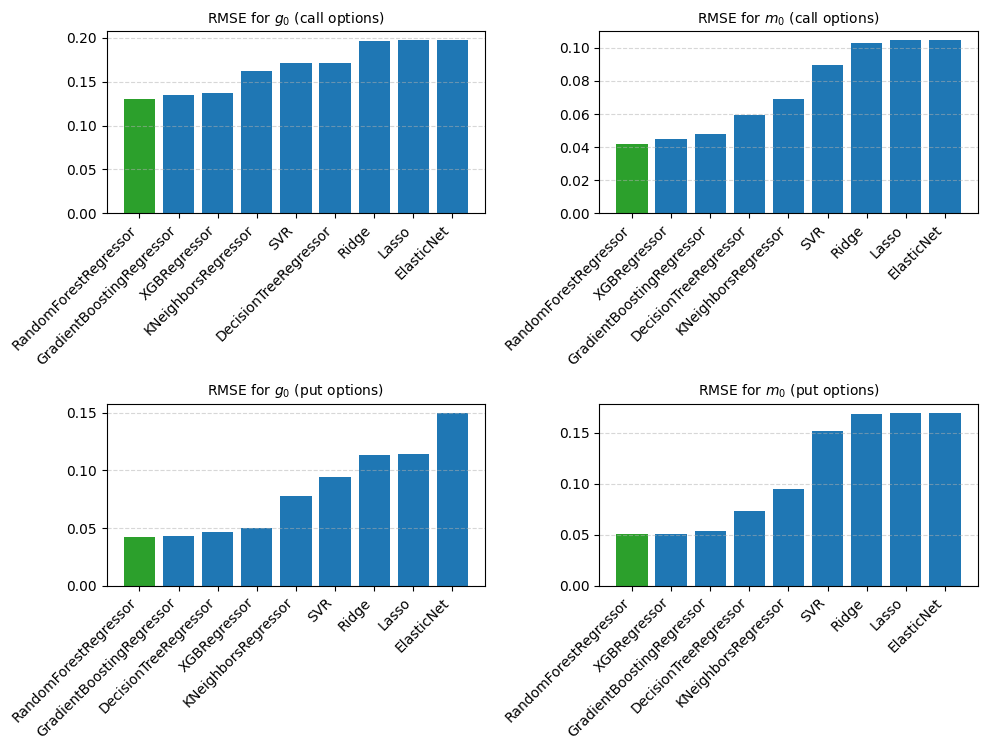

In [313]:
# Figure
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
titles = [
    "RMSE for $g_0$ (call options)",
    "RMSE for $m_0$ (call options)",
    "RMSE for $g_0$ (put options)",
    "RMSE for $m_0$ (put options)"
]

# Loop
df_results = pd.DataFrame(results)
for ax, (otype, target), title in zip(axs.flat, combinations, titles):
    subset = df_results[(df_results["option_type"] == otype) & (df_results["target"] == target)]
    barplot_rmse(subset, title, ax)

plt.tight_layout(rect=[0, 0.05, 1, 1])
# plt.savefig("rmse_models_subplot.png", dpi=300)
plt.show()

From RMSE comparison across DML we can appreciate some interesting results:

- **Random Forests** consistently achieves the lowest mean RMSE across all four configurations;
- **Ensemble models** (Random Forests, Gradient Boosting, XGBoost) strongly outperform linear models (Lasso, Ridge, Elastic Net) in all scenarios.\
This highlights the presence of **nonlinearities** in the relationship between the covariates (`X`) and both `Y` and `D`, and justifies the use of Double Machine Learning techniques over Double Lasso, focused only on linear relationships in the nuisance functions.
- The lowest RMSE and biggest performance gap between top-performing models and linear baselines is particularly pronounced in `put options`.
- Model ranking is consistent across calls and puts, suggesting model stability, even if call options for `g(X)` have higher RMSE.

#### **5** - Estimating the Causal Effect $\theta_0$

In the final stage of the analysis, I aim to estimate the causal effect of **liquidity costs** (proxied by the bid-ask spread) on **Implied Volatility**.

The final estimation of the causal effect $\theta_0$ is obtained by regressing the residualized outcome $\tilde{Y} = Y - \hat{g}(X)$ on the residualized treatment $\tilde{D} = D - \hat{m}(X)$, using cross-fitting to avoid overfitting and ensure valid inference.

*With $\hat{g}(X)$ and $\hat{m}(X)$ estimated using only out-of-sample folds, consistently with the orthogonalization principle in DML.*


Following the RMSE-based model selection from the previous section, I will use the **best-performing models** for the nuisance functions:

- **Random Forest**
- **Gradient Boosting**
- **XGBoost**

Each model is tested on both call and put options. 

The following code estimates $\theta_0$, standard error, p-value, and confidence interval for each configuration.


In [335]:
def estimate_theta(opt_db, otype, regressor, best_models):
    _, Y, D, X = filtering(opt_db, otype=otype)
    splits = dml_cf_splitting(X, splits=5)

    tilde_Y = np.zeros_like(Y)
    tilde_D = np.zeros_like(D)

    # Nuisance functions estimated with the final models
    model_g = regressor(**best_models[(otype, "g")][regressor]["params"])
    model_m = regressor(**best_models[(otype, "m")][regressor]["params"])

    # Calculating Residuals on the splits
    for train_idx, test_idx in splits:
        X_train, X_test = X[train_idx], X[test_idx]
        Y_train, D_train = Y[train_idx], D[train_idx]

        model_g.fit(X_train, Y_train)
        model_m.fit(X_train, D_train)

        tilde_Y[test_idx] = Y[test_idx] - model_g.predict(X_test)
        tilde_D[test_idx] = D[test_idx] - model_m.predict(X_test)

    # Ordinary Least Square Regression
    model = sm.OLS(tilde_Y, sm.add_constant(tilde_D)).fit()
    ci = model.conf_int()

    return {
        "option_type": otype,
        "regressor": regressor.__name__,
        "theta_hat": float(model.params[1]),
        "std_err": float(model.bse[1]),
        "p_value": float(model.pvalues[1]),
        "conf_int 2.5%": float(ci[1][0]),
        "conf_int 97.5%": float(ci[1][1]),
        "n_obs": len(Y)
    }

In [336]:
final_models = [RandomForestRegressor,GradientBoostingRegressor,XGBRegressor]
results = []

for regressor in final_models:
    for otype in ["call", "put"]:
        res = estimate_theta(opt_db, otype, regressor, best_models)
        results.append(res)

df_results = pd.DataFrame(results)
display(df_results)

,option_type,regressor,theta_hat,std_err,p_value,conf_int 2.5%,conf_int 97.5%,n_obs
0,call,RandomForestRegressor,-0.012812,0.042365,0.762352,-0.095865,0.070242,5348
1,put,RandomForestRegressor,-0.003585,0.011922,0.763686,-0.026957,0.019788,5039
2,call,GradientBoostingRegressor,0.017843,0.038215,0.640580,-0.057073,0.092759,5348
3,put,GradientBoostingRegressor,0.032427,0.011453,0.004654,0.009975,0.054880,5039
4,call,XGBRegressor,-0.007588,0.041583,0.855211,-0.089107,0.073931,5348
5,put,XGBRegressor,0.029885,0.014419,0.038265,0.001617,0.058153,5039


## Conclusions

In this study, we estimated the **causal effect of liquidity (proxied by bid-ask spread)** on **implied volatility**, following the Double Machine Learning framework by [Chernouzhoukov et.al. (2018)](https://academic.oup.com/ectj/article-abstract/21/1/C1/5056401?redirectedFrom=fulltext) and replicating the approach proposed in [Li, Lin, Yu, Liu (2025)](https://www.sciencedirect.com/science/article/abs/pii/S0927538X24003974?utm_source=chatgpt.com).

Key findings are as follows:

- The causal effect is **positive and statistically significant only for put options**, with an estimated magnitude between **3% and 4%**, depending on the model used.\
This result confirms the main insight from the reference paper: **liquidity costs systematically amplify implied volatility in the put segment** of the options market.

- For **call options**, the effect is not statistically significant, possibly due to **higher baseline liquidity** and **lower sensitivity** to microstructure frictions such as bid-ask spread.

- Among all tested models, **`Gradient Boosting`** achieved the strongest results, with **lower standard errors**, **narrower confidence intervals**, and **more significant p-values**.

- Regarding the other two top-performing models:

  - `XGBoost` also detects significant effects in the put market, consistently with the original paper.
  - In contrast, `Random Forest`, while achieving the lowest RMSE during tuning, fails to capture significant effects in the final causal regression, possibly due to **overfitting in the estimation of nuisance functions**.

*These results support the interpretation that liquidity costs act as a structural amplifier of volatility perception, particularly in asymmetric or less liquid settings like put options during periods of market stress.*

> While the findings are qualitatively aligned with those of Li et al. (2025), the overall statistical power is slightly lower, likely due to:
> - A **smaller time window** and **limited sample size**;
> - Use of **live option data** from Yahoo Finance, as opposed to historical data providers;
> - Market differences between **CSI 300** (Chinese index) and **QQQ** (Nasdaq).

## References

*Pengshi Li, Yan Lin, Xing Yu, Guifang Liu, 2025. Does bid-ask spread explains the smile? On DVF and DML. Pacific-Basin Finance Journal 90 (2025) 102645.*

*Bernard Dumas, Jeff Fleming, Robert E. Whaley, 2002. Implied Volatility Functions: Empirical Tests. The Journal of Finance 53, Issue 6 (1998).*

*Kim, (2009). The performance of traders' rules in options market. The Journal of Futures Markets 29, Issue 6 (2009).*

*Derman, Kani, (1994). The Volatility Smile and its Implied Tree. Quantitative Strategies Research Notes, Goldman Sachs.*

*Peña, Juan Ignacio and Rubio, Gonzalo A. and Serna Calvo, Gregorio, Smiles, Bid-Ask Spread and Option Pricing. Available at SSRN: https://ssrn.com/abstract=233340 .*

*Victor Chernozhukov ,  Denis Chetverikov ,  Mert Demirer ,  Esther Duflo ,  Christian Hansen , Whitney Newey ,  James Robins, (2018). The Econometrics Journal, Volume 21, Issue 1, 1 February 2018, Pages C1–C68*